# **Load + drop redundant columns**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_excel("Week 2 (DataSet).xlsx", sheet_name="Steel_industry_data")

df['date'] = pd.to_datetime(df['date'])
df['hour'] = df['date'].dt.hour
df['month'] = df['date'].dt.month
df['is_weekend'] = df['date'].dt.dayofweek.isin([5, 6]).astype(int)

df['Power_Factor_Ratio'] = np.where(
    (df['Leading_Current_Power_Factor'] == 0) & (df['Lagging_Current_Power_Factor'] == 0),
    1.0,
    df['Leading_Current_Power_Factor'] / df['Lagging_Current_Power_Factor']
)

# Drop: date (raw), High_Load (direct leak), CO2 (near-duplicate of target), NSM (redundant with hour)
df = df.drop(columns=['date', 'CO2(tCO2)', 'NSM'])

# **Encoding**

In [4]:
# One-hot encoding for Load_Type, Day_of_week, WeekStatus — these are nominal categories
# with no natural order, so one-hot avoids implying a false ranking (e.g. label encoding
# would make "Wednesday" > "Monday" numerically, which means nothing here).
df_encoded = pd.get_dummies(df, columns=['Load_Type', 'Day_of_week', 'WeekStatus'], drop_first=True)

# **Train/test split**

In [5]:
X = df_encoded.drop(columns=['Usage_kWh'])
y = df_encoded['Usage_kWh']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Model Training**

In [6]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results[name] = {"model": model, "MAE": mae, "RMSE": rmse, "R2": r2, "preds": preds}

    print(f"{name}")
    print(f"  MAE:  {mae:.3f}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  R2:   {r2:.4f}")
    print()

Linear Regression
  MAE:  5.755
  RMSE: 8.246
  R2:   0.9402

Ridge Regression
  MAE:  5.749
  RMSE: 8.247
  R2:   0.9402

Decision Tree
  MAE:  0.530
  RMSE: 1.345
  R2:   0.9984

Random Forest
  MAE:  0.270
  RMSE: 0.821
  R2:   0.9994



# **5-fold cross-validation**

In [7]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores)
    results[name]["CV_RMSE_mean"] = cv_rmse.mean()
    results[name]["CV_RMSE_std"] = cv_rmse.std()
    print(f"{name}: CV RMSE = {cv_rmse.mean():.3f} (+/- {cv_rmse.std():.3f})")

Linear Regression: CV RMSE = 8.152 (+/- 0.097)
Ridge Regression: CV RMSE = 8.152 (+/- 0.097)
Decision Tree: CV RMSE = 1.427 (+/- 0.059)
Random Forest: CV RMSE = 0.867 (+/- 0.066)


# **Bar chart comparing test RMSE**

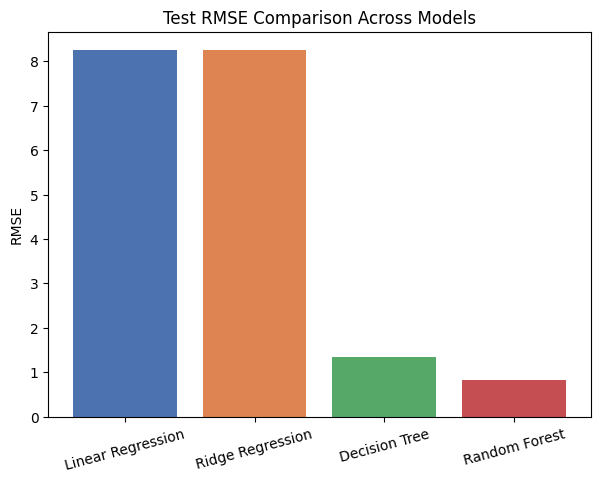

In [8]:
names = list(results.keys())
rmse_vals = [results[n]["RMSE"] for n in names]

plt.figure(figsize=(7, 5))
plt.bar(names, rmse_vals, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
plt.title("Test RMSE Comparison Across Models")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.show()

# **Predicted vs Actual scatter for best model**

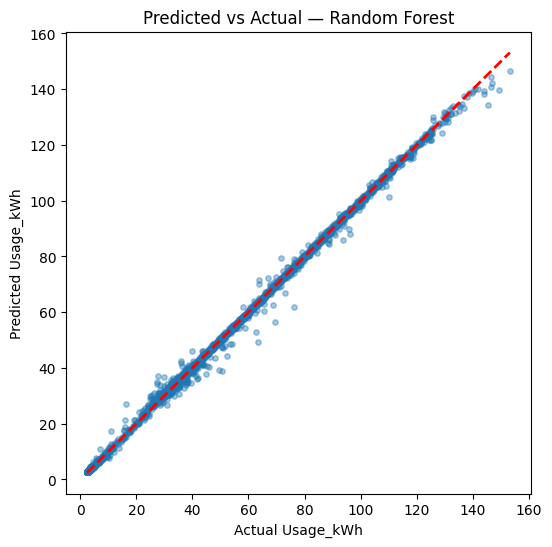

Best model: Random Forest


In [9]:
best_model_name = min(results, key=lambda n: results[n]["RMSE"])
best_preds = results[best_model_name]["preds"]

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_preds, alpha=0.4, s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Usage_kWh")
plt.ylabel("Predicted Usage_kWh")
plt.title(f"Predicted vs Actual — {best_model_name}")
plt.show()

print(f"Best model: {best_model_name}")

In [10]:
for name, model in models.items():
    train_preds = model.predict(X_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    train_r2 = r2_score(y_train, train_preds)

    print(f"{name}")
    print(f"  Train RMSE: {train_rmse:.3f}  |  Test RMSE: {results[name]['RMSE']:.3f}")
    print(f"  Train R2:   {train_r2:.4f}  |  Test R2:   {results[name]['R2']:.4f}")
    print()

Linear Regression
  Train RMSE: 8.119  |  Test RMSE: 8.246
  Train R2:   0.9408  |  Test R2:   0.9402

Ridge Regression
  Train RMSE: 8.119  |  Test RMSE: 8.247
  Train R2:   0.9408  |  Test R2:   0.9402

Decision Tree
  Train RMSE: 0.000  |  Test RMSE: 1.345
  Train R2:   1.0000  |  Test R2:   0.9984

Random Forest
  Train RMSE: 0.319  |  Test RMSE: 0.821
  Train R2:   0.9999  |  Test R2:   0.9994



## Model Selection

Four models were trained and evaluated: Linear Regression, Ridge Regression, Decision Tree, and Random Forest.

| Model              | Train RMSE | Test RMSE | Train R2 | Test R2 | CV RMSE (mean) | CV RMSE (std) |
|---------------------|------------|-----------|----------|---------|-----------------|-----------------|
| Linear Regression   | 8.119      | 8.246     | 0.9408   | 0.9402  | 8.152           | 0.097           |
| Ridge Regression    | 8.119      | 8.247     | 0.9408   | 0.9402  | 8.152           | 0.097           |
| Decision Tree       | 0.000      | 1.345     | 1.0000   | 0.9984  | 1.427           | 0.059           |
| Random Forest       | 0.319      | 0.821     | 0.9999   | 0.9994  | 0.867           | 0.066           |

**Best model: Random Forest**, with the lowest test RMSE (0.821) and lowest CV RMSE (0.867).

Linear and Ridge show almost no gap between train and test RMSE (8.119 vs 8.246), which is expected for a simple linear model , there's little complexity to overfit with. Their higher error compared to the tree-based models suggests the relationship between the features and `Usage_kWh` isn't purely linear.

The Decision Tree shows clear overfitting: train RMSE is 0.000 with a perfect R2 of 1.0000, meaning it memorized the training data exactly, as an unconstrained tree will keep splitting until every training point is fit. Its test RMSE (1.345) is still reasonably low, but the large train/test gap means it's less trustworthy on new data than the metrics alone suggest.

Random Forest also shows a train/test gap (0.319 vs 0.821) but a much smaller one, which is normal for this model , individual trees in the forest overfit, but averaging their predictions reduces variance. This is supported by the CV results: Random Forest's CV RMSE (0.867) stays close to its test RMSE (0.821) with a low standard deviation (0.066), meaning performance is stable across different data splits rather than dependent on one favorable split.

**Model carried forward: Random Forest.** It has the lowest test and CV RMSE, the highest R2, and while it shows mild overfitting, it generalizes far more reliably than the Decision Tree, which memorized the training set outright.